#  Week 3 — Predictive Modeling: Cancellation Prediction



---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.metrics         import (accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report)
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
os.makedirs('../models', exist_ok=True)
os.makedirs('../dashboard/charts', exist_ok=True)

print("All ML libraries imported!")

All ML libraries imported!


---
## Step 2 — Load Data & Select Features




In [2]:
df = pd.read_csv('../data/hotel_bookings_cleaned.csv')
print(f"Data loaded: {df.shape[0]:,} rows")

FEATURES = [
    'lead_time',                    # Days booked in advance  (TOP predictor)
    'adr',                          # Room price per night
    'total_nights',                 # Total stay duration
    'total_guests',                 # Number of guests
    'total_of_special_requests',    # Engagement level
    'booking_changes',              # Times booking was changed
    'previous_cancellations',       # Past cancellation history
    'days_in_waiting_list',         # Urgency / demand
    'hotel',                        # City Hotel vs Resort Hotel
    'deposit_type',                 # Type of deposit paid
    'customer_type',                # Transient, Contract, Group
    'market_segment',               # How they booked
    'season',                       # Time of year
    'traveler_type',                # Leisure / Corporate / Last-Minute
    'is_weekend_booking',           # Weekend flag
    'has_special_request',          # Special request flag
]

TARGET = 'is_canceled'

mdf = df[FEATURES + [TARGET]].dropna()
print(f"Rows for modeling   : {len(mdf):,}")
print(f"Features selected   : {len(FEATURES)}")
print(f"Cancellation rate   : {mdf[TARGET].mean()*100:.1f}%")
print()
print("Selected Features:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i:02d}. {f}")

Data loaded: 10,000 rows
Rows for modeling   : 10,000
Features selected   : 16
Cancellation rate   : 40.0%

Selected Features:
  01. lead_time
  02. adr
  03. total_nights
  04. total_guests
  05. total_of_special_requests
  06. booking_changes
  07. previous_cancellations
  08. days_in_waiting_list
  09. hotel
  10. deposit_type
  11. customer_type
  12. market_segment
  13. season
  14. traveler_type
  15. is_weekend_booking
  16. has_special_request


---
## Step 3 — Encode Categorical Columns



In [3]:
cat_cols = ['hotel','deposit_type','customer_type',
            'market_segment','season','traveler_type']

le = LabelEncoder()
for col in cat_cols:
    mdf[col] = le.fit_transform(mdf[col].astype(str))

mdf['is_weekend_booking']  = mdf['is_weekend_booking'].astype(int)
mdf['has_special_request'] = mdf['has_special_request'].astype(int)

print("Encoding done! Sample:")
mdf[['hotel','deposit_type','season','traveler_type']].head(5)

Encoding done! Sample:


,hotel,deposit_type,season,traveler_type
0,0,1,0,3
1,1,0,1,0
2,1,0,2,1
3,0,0,2,1
4,0,0,2,1


---
## Step 4 — Train-Test Split



In [4]:
X = mdf[FEATURES]
y = mdf[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train-Test Split Complete!")
print(f"  Training rows : {X_train.shape[0]:,}")
print(f"  Testing rows  : {X_test.shape[0]:,}")
print(f"  Train cancel% : {y_train.mean()*100:.1f}%")
print(f"  Test  cancel% : {y_test.mean()*100:.1f}%  (same ratio — good!)")

Train-Test Split Complete!
  Training rows : 8,000
  Testing rows  : 2,000
  Train cancel% : 40.0%
  Test  cancel% : 40.0%  (same ratio — good!)


---
## Step 5 — Feature Scaling


In [5]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Scaling done!")
print(f"  Original lead_time range  : {X['lead_time'].min():.0f} — {X['lead_time'].max():.0f}")
print(f"  Scaled  lead_time range   : {X_train_s[:,0].min():.2f} — {X_train_s[:,0].max():.2f}")

Scaling done!
  Original lead_time range  : 0 — 500
  Scaled  lead_time range   : -0.97 — 3.95


---
## Step 6 — Model 1: Logistic Regression


In [6]:
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_s, y_train)

y_pred_lr = lr.predict(X_test_s)
y_prob_lr = lr.predict_proba(X_test_s)[:,1]

lr_m = {
    'Model'    : 'Logistic Regression',
    'Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_lr, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred_lr, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_lr),
}
print()
print("Logistic Regression Results:")
print(f"  Accuracy  : {lr_m['Accuracy']*100:.2f}%")
print(f"  Precision : {lr_m['Precision']*100:.2f}%")
print(f"  Recall    : {lr_m['Recall']*100:.2f}%   <- KEY metric for hospitality")
print(f"  F1-Score  : {lr_m['F1-Score']*100:.2f}%")
print(f"  ROC-AUC   : {lr_m['ROC-AUC']:.4f}")

Training Logistic Regression...

Logistic Regression Results:
  Accuracy  : 60.00%
  Precision : 49.95%
  Recall    : 63.20%   <- KEY metric for hospitality
  F1-Score  : 55.80%
  ROC-AUC   : 0.6536


---
## Step 7 — Model 2: Decision Tree



In [7]:
print("Training Decision Tree...")
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=50,
                             class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

dt_m = {
    'Model'    : 'Decision Tree',
    'Accuracy' : accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_dt, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred_dt, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_dt),
}
print()
print("Decision Tree Results:")
print(f"  Accuracy  : {dt_m['Accuracy']*100:.2f}%")
print(f"  Precision : {dt_m['Precision']*100:.2f}%")
print(f"  Recall    : {dt_m['Recall']*100:.2f}%   <- KEY metric for hospitality")
print(f"  F1-Score  : {dt_m['F1-Score']*100:.2f}%")
print(f"  ROC-AUC   : {dt_m['ROC-AUC']:.4f}")

Training Decision Tree...

Decision Tree Results:
  Accuracy  : 60.30%
  Precision : 50.24%
  Recall    : 65.08%   <- KEY metric for hospitality
  F1-Score  : 56.71%
  ROC-AUC   : 0.6533


---
## Step 8 — Confusion Matrices



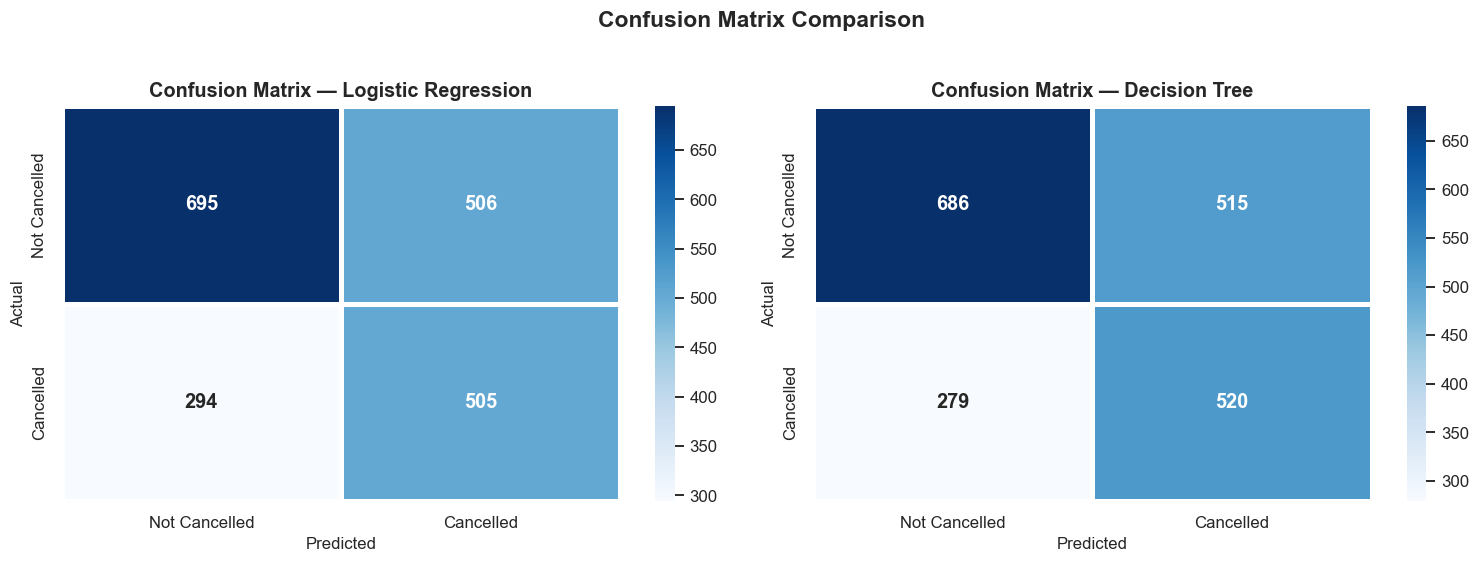

Confusion matrices plotted!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for ax, (name, yp) in zip(axes, [('Logistic Regression', y_pred_lr),
                                   ('Decision Tree',       y_pred_dt)]):
    cm = confusion_matrix(y_test, yp)
    annot = np.array([[f"{cm[i,j]}" for j in range(2)] for i in range(2)])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=2,
                xticklabels=['Not Cancelled','Cancelled'],
                yticklabels=['Not Cancelled','Cancelled'],
                annot_kws={'size':13,'fontweight':'bold'})
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11)

plt.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../dashboard/charts/10_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()
print("Confusion matrices plotted!")

---
## Step 9 — ROC Curves


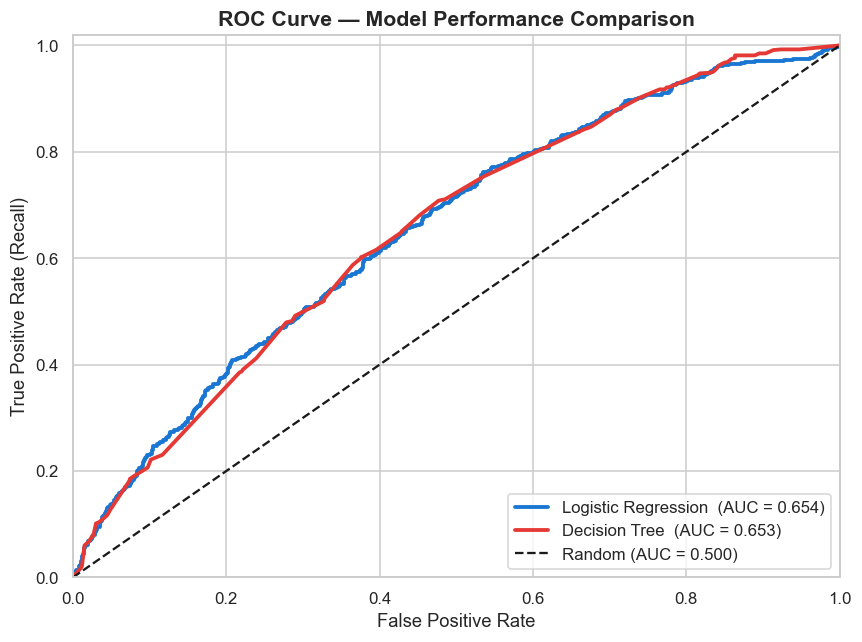

Logistic Regression AUC : 0.6536
Decision Tree AUC       : 0.6533


In [9]:
fig, ax = plt.subplots(figsize=(8,6))

for name, yp, color in [('Logistic Regression', y_prob_lr, '#1976D2'),
                          ('Decision Tree',       y_prob_dt, '#E53935')]:
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)
    ax.plot(fpr, tpr, linewidth=2.5, color=color, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--', linewidth=1.5, label='Random (AUC = 0.500)')
ax.set_title('ROC Curve — Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('../dashboard/charts/11_roc_curves.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Logistic Regression AUC : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Decision Tree AUC       : {roc_auc_score(y_test, y_prob_dt):.4f}")

---
## Step 10 — Feature Importance



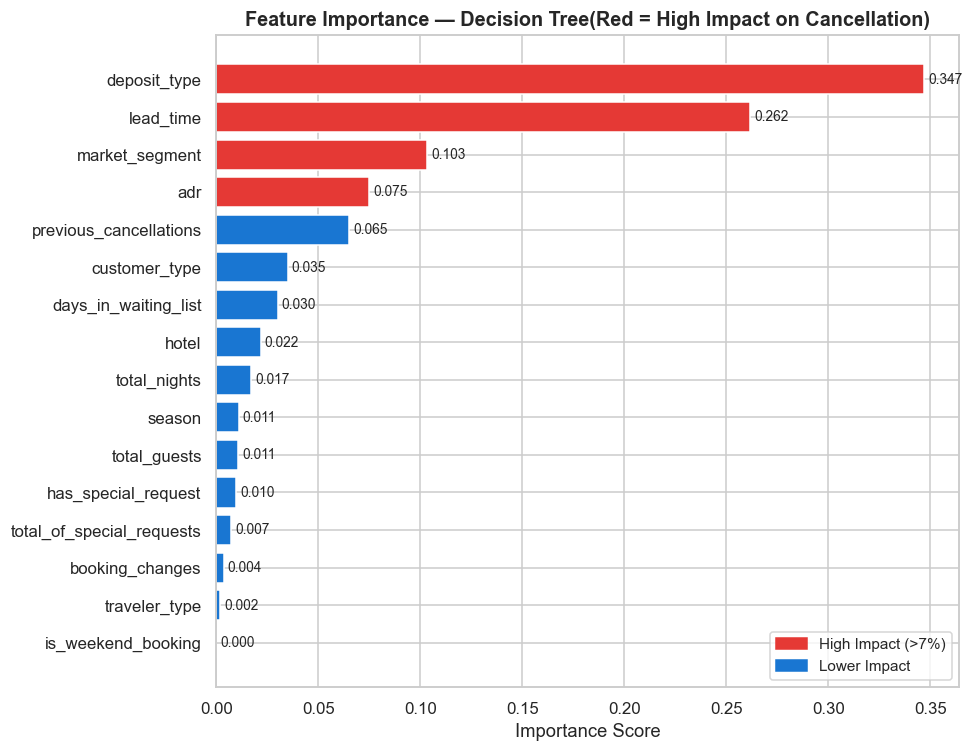

Top 5 Cancellation Predictors:
  deposit_type                       : 34.7%
  lead_time                          : 26.2%
  market_segment                     : 10.3%
  adr                                : 7.5%
  previous_cancellations             : 6.5%


In [11]:
fi = pd.DataFrame({'Feature':FEATURES, 'Importance':dt.feature_importances_}
                ).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9,7))
colors = ['#E53935' if v > 0.07 else '#1976D2' for v in fi['Importance']]
ax.barh(fi['Feature'], fi['Importance'], color=colors, edgecolor='white')

for i, v in enumerate(fi['Importance']):
    ax.text(v+0.002, i, f"{v:.3f}", va='center', fontsize=9)

ax.set_title('Feature Importance — Decision Tree(Red = High Impact on Cancellation)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#E53935',label='High Impact (>7%)'),
                   Patch(color='#1976D2',label='Lower Impact')],
          fontsize=10, loc='lower right')
plt.tight_layout()
plt.savefig('../dashboard/charts/12_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print("Top 5 Cancellation Predictors:")
for _, row in fi.sort_values('Importance',ascending=False).head(5).iterrows():
    print(f"  {row['Feature']:<35}: {row['Importance']*100:.1f}%")

---
## Step 11 — Model Comparison Bar Chart


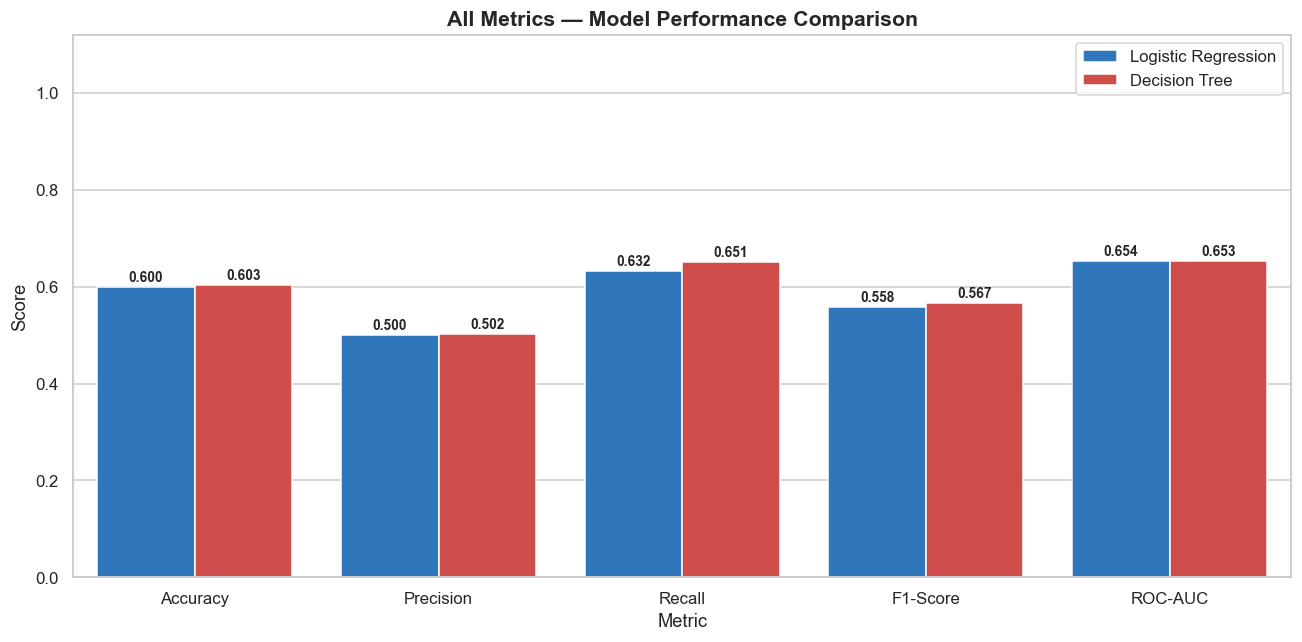

FINAL COMPARISON
 Logistic Regression
    Accuracy  : 60.00%
    Recall    : 63.20%  <- Most important!
    ROC-AUC   : 0.6536
 Decision Tree
    Accuracy  : 60.30%
    Recall    : 65.08%  <- Most important!
    ROC-AUC   : 0.6533


In [13]:
import pandas as pd
metrics_df = pd.DataFrame([lr_m, dt_m])
melt = metrics_df.melt(id_vars='Model',
    value_vars=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'],
    var_name='Metric', value_name='Score')

fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=melt, x='Metric', y='Score', hue='Model',
            palette={'Logistic Regression':'#1976D2','Decision Tree':'#E53935'}, ax=ax)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}',
            (p.get_x()+p.get_width()/2, p.get_height()+0.005),
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('All Metrics — Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0,1.12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../dashboard/charts/13_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

print("=" * 55)
print("FINAL COMPARISON")
print("=" * 55)
for m in [lr_m, dt_m]:
    
    print(f" {m['Model']}")
    print(f"    Accuracy  : {m['Accuracy']*100:.2f}%")
    print(f"    Recall    : {m['Recall']*100:.2f}%  <- Most important!")
    print(f"    ROC-AUC   : {m['ROC-AUC']:.4f}")

---
## Step 12 — Save Trained Models



In [14]:
joblib.dump(dt,     '../models/decision_tree_model.pkl')
joblib.dump(lr,     '../models/logistic_regression_model.pkl')
joblib.dump(scaler, '../models/feature_scaler.pkl')

print("Models saved to models/ folder:")
print("  decision_tree_model.pkl        (best model)")
print("  logistic_regression_model.pkl  (baseline)")
print("  feature_scaler.pkl             (scaler for LR)")

Models saved to models/ folder:
  decision_tree_model.pkl        (best model)
  logistic_regression_model.pkl  (baseline)
  feature_scaler.pkl             (scaler for LR)
